## Physics-Informed Neural Network tutorial

In this tutorial, we will construct a simple example of PINN to solve a 1-D problem using no data beyond boundary conditions.

This will be based on the python module PyTorch.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

Our goal will be to recover the function $f(x) = e^{-x}$ over the domain $[0,1]$, while knowing only the ODE $\frac{df}{dx} = -f$ and the boudary condition $f(0)=1$.

In [ ]:
# Exact solution

def f(x):
    return np.exp(-x)

### - Architecture

We start by chosing an architecture for our network. We want to create a continuous PINN, i.e. a network that takes as input the coordinate $x$, and returns as output the state $f(x)$.

In this simple 1-D case, our network takes 1 variable as input and 1 variable as output.
We chose to use a simple Multi Layer Perceptron (MLP) with 2 hidden layers of width 10. (This needs to be adjusted based on the complexity of the tackled problem.)

In [ ]:
class simple_MLP(torch.nn.Module):

    def __init__(self):
        super(simple_MLP, self).__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(1, 10),
            torch.nn.Tanh(),
            torch.nn.Linear(10, 10),
            torch.nn.Tanh(),
            torch.nn.Linear(10, 1)
            )

    def forward(self, x):
        return self.net(x)

model = simple_MLP()

### - Data

In this simple case, we need no data to accomplish the task. In a more complex problem, however, it can be beneficial to include information on known values of the system state. This would result in an additional term in the loss function.

### - Loss function

Our loss function should include:
- A term to enforce the ODE
- A term to enforce the boundary condition

For the ODE term:
- Put the ODE in the form $N[f] = 0$, where $N$ is a differential operator. Here: $\frac{df}{dx} + f = 0$
- Chose the amount of collocation points $N_{col}$.
- Randomly select $N_{col}$ points in the domain.
- In the loss function, evaluate $N[f]$ at each collocation point, and add the mean square residual to the loss.


In [ ]:
# ODE loss - Collocation point selection

ncol = 5
collocation = torch.rand(ncol, 1)
collocation.requires_grad = True

# ODE loss - Loss function

def ODEloss(model, x):
    fx = model(x)

    # Derivative are computed using pytorch's autograd
    dfdx = torch.autograd.grad(fx, x, grad_outputs=torch.ones_like(fx), create_graph=True)[0]

    # ODE: du/dx + u = 0
    residual = dfdx + fx

    return torch.mean(residual**2)

For the boundary term, here we only have a single point, so we can directly add the mean square error to the loss.

If we had a boundary domain, as opposed to a finite set of points, we would also draw a set of collocation points to evaluate boundary conditions at.

In [ ]:
# BC loss - Collocation point

x_bc = torch.tensor([[0.]])
val_bc = torch.tensor([[1.]])

# BC loss - Loss function

def BCloss(model, locations=x_bc, values=val_bc):
    f_pred = model(locations)
    return torch.mean((f_pred - values)**2)

Now we have all we need to define the full loss function.

In [ ]:
# Full loss function

def full_loss(model, x):
  return ODEloss(model, x) + BCloss(model)

### - Optimization process

We need to chose an optimiser. For this simple task, we take ADAM, with a learning rate of 0.01.

In [ ]:
# Optimizer

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
# Training loop

epochs = 2000

for epoch in range(epochs):
    optimizer.zero_grad()

    # Compute losses
    loss = full_loss(model, collocation)

    # Backpropagation
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: Total Loss = {loss.item():.6f}")

Epoch 0: Total Loss = 0.774561
Epoch 100: Total Loss = 0.000021
Epoch 200: Total Loss = 0.000008
Epoch 300: Total Loss = 0.000007
Epoch 400: Total Loss = 0.000007
Epoch 500: Total Loss = 0.000006
Epoch 600: Total Loss = 0.000006
Epoch 700: Total Loss = 0.000006
Epoch 800: Total Loss = 0.000006
Epoch 900: Total Loss = 0.000006
Epoch 1000: Total Loss = 0.000006
Epoch 1100: Total Loss = 0.000006
Epoch 1200: Total Loss = 0.000005
Epoch 1300: Total Loss = 0.000005
Epoch 1400: Total Loss = 0.000005
Epoch 1500: Total Loss = 0.000005
Epoch 1600: Total Loss = 0.000005
Epoch 1700: Total Loss = 0.000005
Epoch 1800: Total Loss = 0.000005
Epoch 1900: Total Loss = 0.000005


Now, let's visualize the results.

In [ ]:
x_test = np.linspace(0, 1, 100)

# Generate ground truth data
f_gt = f(x_test)

# Get model predicted data
f_pred = model(torch.tensor(x_test.reshape(-1,1), dtype=torch.float32)).detach().numpy()

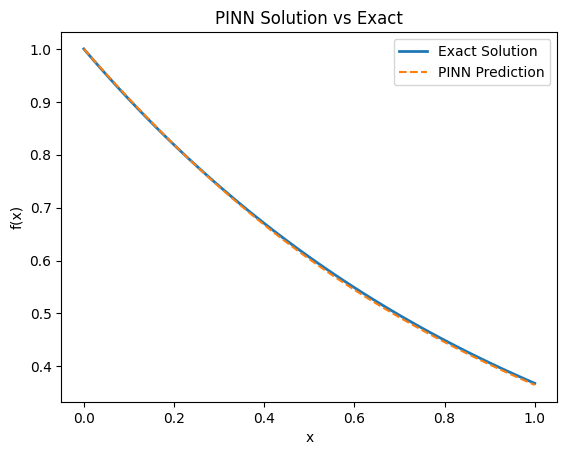

In [ ]:
plt.figure()
plt.plot(x_test, f_gt, label="Exact Solution", linewidth=2)
plt.plot(x_test, f_pred, '--', label="PINN Prediction")
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("PINN Solution vs Exact")
plt.show()

Additional exercises:

- Try changing the number of collocation points. How many collocation points are really needed for this example to work ?

- Try increasing the size of the prediction domain. How does that affect the number of required collocation points ?

- Add a third loss term (data loss) that enforces that the network respects the exact solution at a defined set of points in the domain. Verify that adding datapoints decreases the amount of collocation points required.

- Rewrite this example for a problem with two spatial coordinates: $f(x,y) = x y$ on the domain $[0,1]²$, using as enforced physical knowledge the Laplace equation $\Delta f = 0$. You can include boundary conditions that use a set of collocation points, or include training data and therefore an additionnal loss term, or both.